# Evaluation Metrics

On an imbalanced dataset, accuracy is misleading.

The following are used:
- AUC
- sensitivity
- specificity
- PPV
- NPV
- F1

The operating threshold comes from Youden'J statistic.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from src.evaluation.metrics import MetricPanel, evaluate, youden_threshold

## Beyond Accuracy

With ~59% benign majority, a model that always predicts benign achieves 59% accuracy.
AUC being threshold independent can give a more honest picture.

In [2]:
np.random.seed(42)

# Synthetic data for demonstration
# 60 benign, 40 malignant
y_true = np.array([0] * 60 + [1] * 40)

# A model that always predicts benign (0)
y_pred = np.zeros(100)
accuracy = (y_true == y_pred).mean() * 100
print(f"Always predicts benign: {accuracy:.1f}%")

Always predicts benign: 60.0%


## Youden's J Threshold

The default 0.5 probability cutoff is arbitrary.
Youden's J finds the threshold that maximises `true positive rate (TPR) - false positive rate (FPR)` on the ROC curve. The point of best trade-off between sensitivity and specificity.

In [3]:
# Synthetic data for demonstration
y_prob = np.concatenate([
    np.random.beta(2, 5, size=60), # benign tend low
    np.random.beta(5, 2, size=40), # malignant tend high
])

threshold = youden_threshold(y_true, y_prob)
print(f"Youden's threshold: {threshold:.4f}")

Youden's threshold: 0.5290


## The Metric Panel
`evaluate` returns a single frozen dataclass bundling all metrics at the chosen threshold.

In [4]:
panel = evaluate(y_true, y_prob)
print(f"Accuracy:\t{panel.accuracy:.4f}")
print(f"AUC:\t\t{panel.auc:.4f}")
print(f"Sensitivity:\t{panel.sensitivity:.4f}")
print(f"Specificity:\t{panel.specificity:.4f}")
print(f"PPV:\t\t{panel.ppv:.4f}")
print(f"NPV:\t\t{panel.npv:.4f}")
print(f"F1 Score:\t{panel.f1:.4f}")
print(f"Threshold:\t{panel.threshold:.4f}")

Accuracy:	0.9400
AUC:		0.9804
Sensitivity:	0.9500
Specificity:	0.9333
PPV:		0.9048
NPV:		0.9655
F1 Score:	0.9268
Threshold:	0.5290


## Confusion Matrix

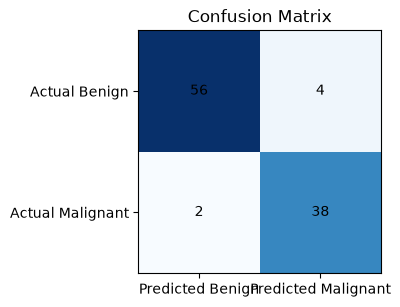

In [5]:
cm = panel.confusion

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap='Blues')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', color='black')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted Benign', 'Predicted Malignant'])
ax.set_yticklabels(['Actual Benign', 'Actual Malignant'])
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()